# Random number generation
Author: Aleksander Filip Żarnecki (University of Warsaw)

### (0) Import libraries 

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

### (1) Define inverse of cumulative distribution of the considered PDF

In [2]:
# Cumulative distribution function for Cauchy distribution is
#
#   F(x) =  np.arctan(x)/np.pi + 0.5
#

def invF(u):
    x = np.tan(np.pi*(u-0.5))
    return x


### (2) Generate a set of random variables from given distribution

In [3]:
# Number of generations

Nmc = 100

u_tab = np.random.uniform(size=Nmc)    # Table of uniformly distributed numbers from [0.,1.[

r_tab = invF(u_tab)                    # Resulting table of numbers from Cauchy distribution


### (3) Plot results

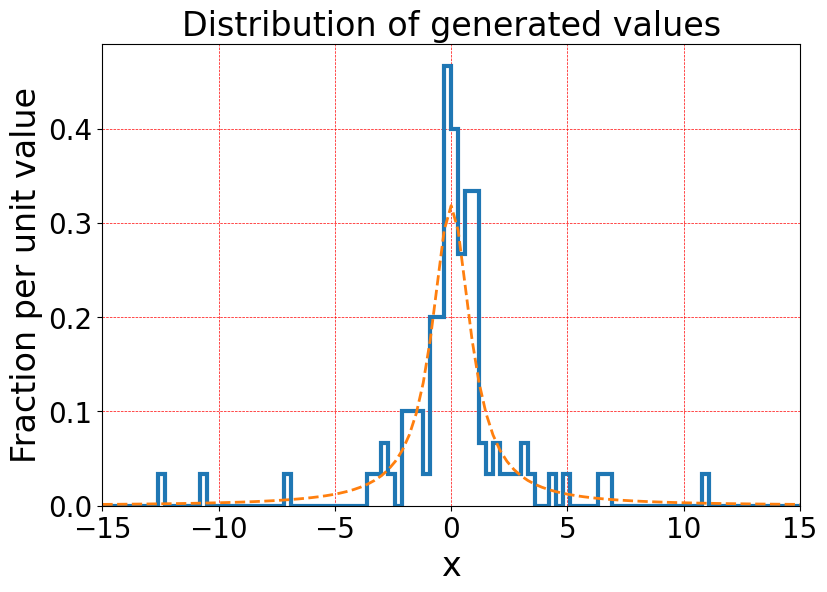

In [4]:
# Range for result histogram

Xmax=15.
Nbin = 100

# Plot histogram

plt.figure(figsize=(9, 6))

plt.hist(r_tab,bins=Nbin, range=[-Xmax,Xmax], density=True, log=False, histtype='step',linewidth=3)

plt.xlabel('x',size=24)
plt.ylabel('Fraction per unit value',size=24)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title("Distribution of generated values",size=24)
plt.grid(which='major', axis='both',color='r', linestyle='--', linewidth=0.5)
plt.xlim([-Xmax,Xmax])

# Expected dependence

def myCauchy(x):
    norm = 1/np.pi
    val = 1/(x**2 + 1)
    return norm*val

x_tab = np.linspace(-Xmax,Xmax,Nbin+1)
y_tab = myCauchy(x_tab)
plt.plot(x_tab,y_tab,'--',linewidth=2)

fname = '04_generate_'+str(Nmc)+'.png'
plt.savefig(fname)

plt.show()